# Notebook 07 — Quick Benchmarks

Four short benchmark experiments: (A) basis convergence, (B) circuit resource scaling, (C) optimizer comparison, (D) C=C bond dissociation curve.

In [1]:
# ── Install dependencies (run once in clean Colab environment) ──
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "pyscf>=2.3", "qiskit>=1.0", "qiskit-aer>=0.14",
    "qiskit-nature>=0.7", "openfermion>=1.6",
    "scipy>=1.11", "matplotlib>=3.7", "pandas>=2.0",
    "h5py>=3.9", "tabulate>=0.9"])
print("✅ All dependencies installed")

✅ All dependencies installed



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, sys
os.environ['PYSCF_MAX_MEMORY'] = '4000'
if not os.path.exists('/content/quantum-alkene-alkyne-pyscf'):
    os.system('git clone https://github.com/Tommaso-R-Marena/quantum-alkene-alkyne-pyscf /content/quantum-alkene-alkyne-pyscf')
os.chdir('/content/quantum-alkene-alkyne-pyscf')
sys.path.insert(0, '/content/quantum-alkene-alkyne-pyscf')
os.makedirs('results', exist_ok=True)
print("✅ Repo loaded, results/ directory ready")

✅ Repo loaded, results/ directory ready


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, datetime, time
import qiskit, pyscf
print(f"qiskit {qiskit.__version__} | pyscf {pyscf.__version__}")

qiskit 2.4.1 | pyscf 2.13.0


## A — Basis convergence (HF + CISD, ethylene)

  basis = sto-3g


  basis = 3-21g


  basis = 6-31g


  basis = 6-31g*


 Basis         HF       CISD
sto-3g -77.072123 -77.222864
 3-21g -77.599765 -77.795661
 6-31g -78.003601 -78.198033
6-31g* -78.030423 -78.293163


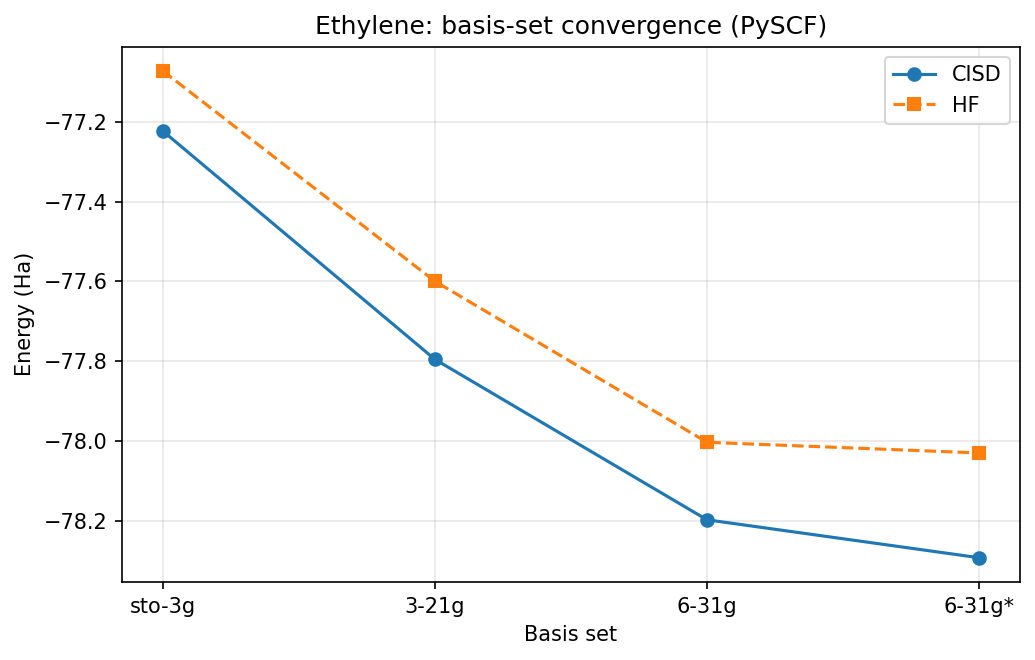

✅ Saved results/basis_convergence_ethylene.png


In [4]:
import warnings; warnings.filterwarnings("ignore")
from src.molecule_builder import run_pyscf_references
from src.hamiltonian_utils import build_qiskit_nature_hamiltonian
from src.vqe_runner import run_uccsd_vqe_qiskit

BASES = ["sto-3g", "3-21g", "6-31g", "6-31g*"]
basis_rows = []
for b in BASES:
    print(f"  basis = {b}")
    try:
        refs = run_pyscf_references("ethylene", basis=b, methods=("HF", "CISD"))
        basis_rows.append({"Basis": b, "HF": refs["HF"], "CISD": refs["CISD"]})
    except Exception as e:
        basis_rows.append({"Basis": b, "HF": float("nan"), "CISD": float("nan")})
        print(f"    failed: {e}")
basis_df = pd.DataFrame(basis_rows)
print(basis_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,4.5), dpi=150)
ax.plot(basis_df["Basis"], basis_df["CISD"], "o-", label="CISD")
ax.plot(basis_df["Basis"], basis_df["HF"], "s--", label="HF")
ax.set_xlabel("Basis set"); ax.set_ylabel("Energy (Ha)")
ax.set_title("Ethylene: basis-set convergence (PySCF)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/basis_convergence_ethylene.png", dpi=150)
plt.show()
print("✅ Saved results/basis_convergence_ethylene.png")


## B — Circuit resource table (UCCSD on ethylene)

In [5]:
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit import transpile

mapper = JordanWignerMapper()
ASES = [(2, 2), (4, 4), (6, 6)]
res_rows = []
for ae, ao in ASES:
    print(f"  active space ({ae}e, {ao}o)")
    try:
        qop, prob = build_qiskit_nature_hamiltonian(
            "ethylene", basis="sto-3g",
            active_electrons=ae, active_orbitals=ao,
        )
        hf = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, mapper)
        ansatz = UCCSD(num_spatial_orbitals=prob.num_spatial_orbitals,
                       num_particles=prob.num_particles,
                       qubit_mapper=mapper, initial_state=hf)
        tqc = transpile(ansatz.decompose(),
                        basis_gates=["u3","cx"],
                        optimization_level=1)
        ops = tqc.count_ops()
        res_rows.append({
            "Active Space": f"({ae}e,{ao}o)",
            "n_qubits": int(qop.num_qubits),
            "n_parameters": int(ansatz.num_parameters),
            "n_2q_gates": int(ops.get("cx", 0)),
            "circuit_depth": int(tqc.depth()),
        })
    except Exception as e:
        res_rows.append({"Active Space": f"({ae}e,{ao}o)",
                         "n_qubits": -1, "n_parameters": -1,
                         "n_2q_gates": -1, "circuit_depth": -1})
        print(f"    failed: {e}")

circ_df = pd.DataFrame(res_rows)
print(circ_df.to_string(index=False))
circ_df.to_csv("results/circuit_resources.csv", index=False)
print("✅ Saved results/circuit_resources.csv")


  active space (2e, 2o)


  active space (4e, 4o)


  active space (6e, 6o)


Active Space  n_qubits  n_parameters  n_2q_gates  circuit_depth
     (2e,2o)         4             3          56             73
     (4e,4o)         8            26        1408           1679
     (6e,6o)        12           117       10008          11467
✅ Saved results/circuit_resources.csv


## C — Optimizer comparison (statevector, ethylene 2e,2o)

In [6]:
import time
from scipy.optimize import minimize
from qiskit_aer.primitives import Estimator as AerEstimator

qop, prob = build_qiskit_nature_hamiltonian(
    "ethylene", basis="sto-3g",
    active_electrons=2, active_orbitals=2,
)
mapper = JordanWignerMapper()
hf = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals=prob.num_spatial_orbitals,
               num_particles=prob.num_particles,
               qubit_mapper=mapper, initial_state=hf)
estimator = AerEstimator(approximation=True, run_options={"shots": None})
shift = sum(prob.hamiltonian.constants.values())

def make_energy_fn():
    calls = [0]
    def f(x):
        calls[0] += 1
        v = float(estimator.run([ansatz], [qop], [x]).result().values[0])
        return v + shift
    return f, calls

opt_rows = []
for opt_name, opts in [
    ("SLSQP",   {"ftol": 1e-9, "maxiter": 500}),
    ("COBYLA",  {"rhobeg": 0.1, "catol": 1e-8, "maxiter": 500}),
    ("L-BFGS-B",{"ftol": 1e-9, "maxiter": 500}),
]:
    x0 = np.zeros(ansatz.num_parameters)
    f, calls = make_energy_fn()
    t0 = time.time()
    res = minimize(f, x0, method=opt_name, options=opts)
    wall = time.time() - t0
    opt_rows.append({
        "Optimizer": opt_name,
        "Final Energy (Ha)": float(res.fun),
        "Wall time (s)": float(wall),
        "Function evals": int(calls[0]),
    })
    print(f"  {opt_name:<10}  E={res.fun:.8f}  calls={calls[0]:4d}  wall={wall:.2f}s")

opt_df = pd.DataFrame(opt_rows)
opt_df.to_csv("results/optimizer_comparison.csv", index=False)
print("✅ Saved results/optimizer_comparison.csv")


  SLSQP       E=-77.11662916  calls=  16  wall=0.27s


  COBYLA      E=-77.11662916  calls=  41  wall=0.37s


  L-BFGS-B    E=-77.11662916  calls=  20  wall=0.26s
✅ Saved results/optimizer_comparison.csv


## D — C=C bond dissociation (PySCF HF + CISD)

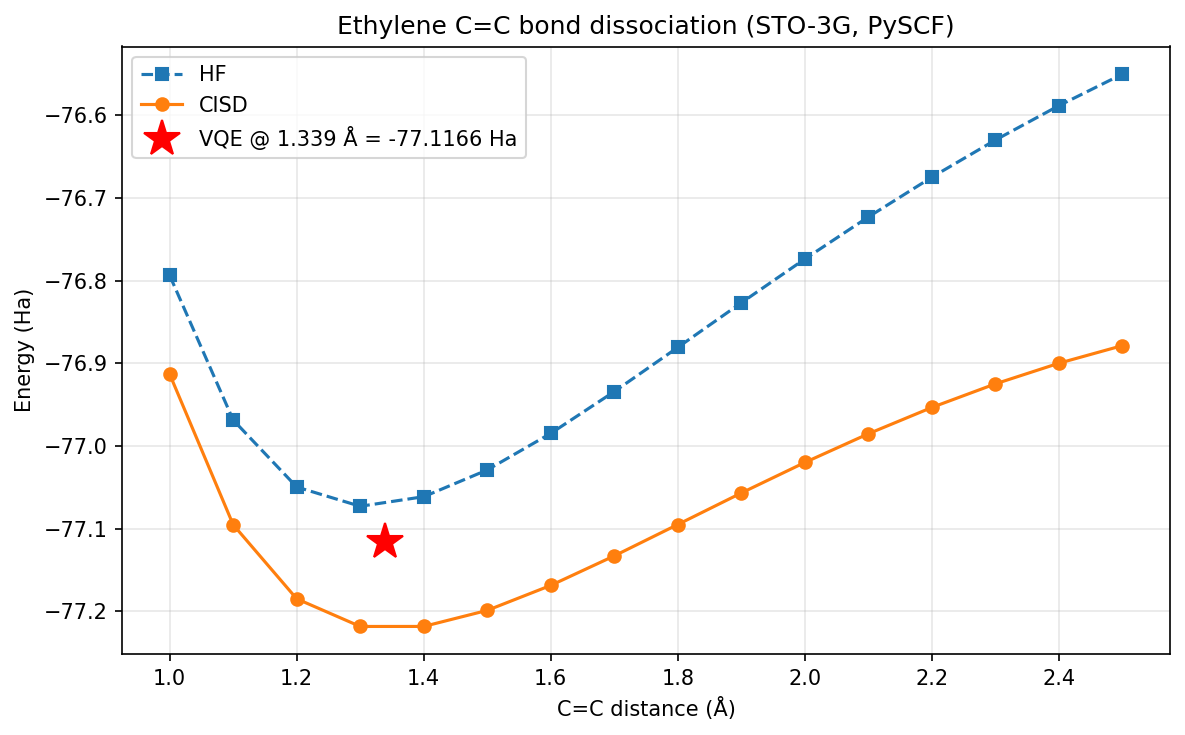

✅ Saved results/bond_dissociation_ethylene.png


In [7]:
import os, json
from pyscf import gto, scf, ci

distances = np.arange(1.0, 2.51, 0.1)
hf_curve, cisd_curve = [], []
for r in distances:
    mol = gto.Mole()
    mol.atom = (f"C 0 0 0; C 0 0 {r:.6f}; "
                "H 0  0.929 -0.547; H 0 -0.929 -0.547; "
                f"H 0  0.929 {r+0.547:.6f}; H 0 -0.929 {r+0.547:.6f}")
    mol.basis = "sto-3g"
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()
    mf = scf.RHF(mol); mf.verbose = 0
    e_hf = float(mf.kernel())
    e_cisd = float(ci.CISD(mf).kernel()[0]) + e_hf
    hf_curve.append(e_hf); cisd_curve.append(e_cisd)

# Overplot equilibrium VQE point if available
vqe_eq_x, vqe_eq_y = None, None
p = "results/ethylene_sto-3g_vqe_results.json"
if os.path.exists(p):
    with open(p) as f: rec = json.load(f)
    vqe_eq_x, vqe_eq_y = 1.339, rec["vqe_energy"]

fig, ax = plt.subplots(figsize=(8,5), dpi=150)
ax.plot(distances, hf_curve, "s--", label="HF")
ax.plot(distances, cisd_curve, "o-", label="CISD")
if vqe_eq_x is not None:
    ax.plot([vqe_eq_x], [vqe_eq_y], "*", ms=18, color="red",
            label=f"VQE @ 1.339 Å = {vqe_eq_y:.4f} Ha")
ax.set_xlabel("C=C distance (Å)")
ax.set_ylabel("Energy (Ha)")
ax.set_title("Ethylene C=C bond dissociation (STO-3G, PySCF)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/bond_dissociation_ethylene.png", dpi=150)
plt.show()
print("✅ Saved results/bond_dissociation_ethylene.png")
